In [151]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [152]:
import sys
from pathlib import Path

root = Path.cwd().parent.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

In [153]:
from src import config

In [154]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [155]:
import random, numpy as np, matplotlib.pyplot as plt

In [156]:
random.seed(42)

### Encoder

In [157]:
class Encoder(nn.Module):
    def __init__(self, input_height, input_width, hidden_dim_1, hidden_dim_2, latent_dim):
        super().__init__()
        self.input_dim = input_height * input_width
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.input_dim, hidden_dim_1),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.LeakyReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim_2, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim_2, latent_dim)
        
    def forward(self, x):
        h = self.net(x) # TODO: i dont understand the syntax here
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar       

### Decoder

In [158]:
class Decoder(nn.Module):
    def __init__(self, output_height, output_width, hidden_dim_1, hidden_dim_2, latent_dim):
        super().__init__()
        self.output_dim = output_height * output_width
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim_2),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim_2, hidden_dim_1),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim_1, self.output_dim),
            # nn.Sigmoid(), # because spectrograms are normalized to 0-1
            nn.Unflatten(1, (output_height, output_width))
        )
        
    def forward(self, z):
        return self.net(z)

### Vanilla/Basic VAE

In [159]:
class VanillaVAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.config = cfg
        self.encoder = Encoder(
            input_height=cfg.INPUT_HEIGHT,
            input_width=cfg.INPUT_WIDTH,
            hidden_dim_1=cfg.HIDDEN_DIM_1,
            hidden_dim_2=cfg.HIDDEN_DIM_2,
            latent_dim=cfg.LATENT_DIM
        )
        self.decoder = Decoder(
            output_height=cfg.INPUT_HEIGHT,
            output_width=cfg.INPUT_WIDTH,
            hidden_dim_1=cfg.HIDDEN_DIM_1,
            hidden_dim_2=cfg.HIDDEN_DIM_2,
            latent_dim=cfg.LATENT_DIM
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
      x_recon = self.decoder(z)
      return x_recon.view(-1, 1, self.config.INPUT_HEIGHT, self.config.INPUT_WIDTH)
  
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

### Dataset Class

In [160]:
class AudioSpectrogramDataset(Dataset):
    def __init__(self, dataset_dir, expected_shape=(config.INPUT_HEIGHT, config.INPUT_WIDTH), add_channel_dim=False):
        super().__init__()
        self.dataset_dir = dataset_dir
        self.file_paths = sorted(self.dataset_dir.rglob("*npy"))
        self.expected_shape = expected_shape
        self.add_channel_dim = add_channel_dim
        self.global_min = -80.0
        self.global_max = 0.0
        
        # mins, maxs = [], []
        # for fp in self.file_paths[:200]:
        #     x = np.load(fp)
        #     mins.append(x.min())
        #     maxs.append(x.max())

        # print("min of mins:", min(mins))
        # print("max of maxs:", max(maxs))
        # print("avg min:", sum(mins)/len(mins))
        # print("avg max:", sum(maxs)/len(maxs))
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, index):
        file_path = self.file_paths[index]
        x = np.load(file_path)
        x = (x - self.global_min) / (self.global_max - self.global_min)
        # x = np.clip(x, 0.0, 1.0)
        x = torch.tensor(x, dtype=torch.float32)
        if self.add_channel_dim: x = x.unsqueeze(0)
        
        return x, str(file_path)

## Activating GPU

In [161]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [162]:
device

device(type='cuda')

## Train and Test Data Preparation

In [163]:
npy_dir = Path("../..") / config.FEATURES_DIR

In [164]:
dataset = AudioSpectrogramDataset(dataset_dir=npy_dir)

In [165]:
BATCH_SIZE = 32

In [166]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

In [167]:
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [168]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=config.SHUFFLE)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [169]:
len(train_dataset), len(test_dataset)

(800, 200)

## Training and Evaluating

In [170]:
def vae_loss(x_hat, x, beta, mu, logvar, epoch): # required for evaluation
    # recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    beta = min(1.0, epoch / 10)
    total = recon + beta * kl # TODO: use beta when and why?
    
    return total, recon, kl

In [171]:
def train_one_epoch(model, loader, optimizer, beta, epoch, device=device):
    model.train()
    total_sum = recon_sum = kl_sum = n = 0
    
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
        loss.backward()
        optimizer.step()

        total_sum += loss.item()
        recon_sum += recon.item()
        kl_sum += kl.item()
        n += x.size(0) # TODO: = 1 because channel?  
              
    train_total = total_sum / max(n, 1)
    train_recon = recon_sum / max(n, 1)
    train_kl = kl_sum / max(n, 1)
    
    return {
        "loss": train_total,
        "recon": train_recon,
        "kl": train_kl
    }

In [172]:
def evaluate(model, loader, beta, epoch, device=device):
    model.eval()
    total_sum = recon_sum = kl_sum = n = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
            
            total_sum += loss.item()
            recon_sum += recon.item()
            kl_sum += kl.item()
            n += x.size(0)

    test_total = total_sum / max(n, 1)
    test_recon = recon_sum / max(n, 1)
    test_kl = kl_sum / max(n, 1)
    
    return {
        "loss": test_total,
        "recon": test_recon,
        "kl": test_kl
    }

In [173]:
def train_vae(model, train_loader, test_loader, optimizer, beta, device=device):
    history = {"train_total": [], "test_total": [],
               "train_recon": [], "test_recon": [],
               "train_kl": [], "test_kl": []}
    for epoch in range(config.EPOCHS):
        train_stats = train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, beta=beta, epoch=epoch, device=device)
        test_stats = evaluate(model=model, loader=test_loader, beta=beta, epoch=epoch, device=device)
        train_total = train_stats["loss"]
        test_total = test_stats["loss"]
        train_recon = train_stats["recon"]
        test_recon = test_stats["recon"]
        train_kl = train_stats["kl"]
        test_kl = test_stats["kl"]
        history["train_total"].append(train_total)
        history["test_total"].append(test_total)
        history["train_recon"].append(train_recon)
        history["test_recon"].append(test_recon)
        history["train_kl"].append(train_kl)
        history["test_kl"].append(test_kl)
        print(
            f"epoch {epoch:02d} | "
            f"train_total={train_total:.4f} recon={train_recon:.4f} kl={train_kl:.4f} | "
            f"test_total={test_total:.4f} recon={test_recon:.4f} kl={test_kl:.4f}"
        )
        
    return history

In [174]:
def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_total"], label="train total")
    plt.plot(history["test_total"], label="test total")
    plt.plot(history["train_recon"], label="train recon")
    plt.plot(history["test_recon"], label="test recon")
    plt.plot(history["train_kl"], label="train kl")
    plt.plot(history["test_kl"], label="test kl")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

## Single Iteration Model

In [175]:
model = VanillaVAE(cfg=config).to(device)

In [176]:
model

VanillaVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=5824, out_features=512, bias=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Linear(in_features=512, out_features=128, bias=True)
      (4): LeakyReLU(negative_slope=0.01)
    )
    (mu_layer): Linear(in_features=128, out_features=32, bias=True)
    (logvar_layer): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=32, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=512, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=512, out_features=5824, bias=True)
      (5): Unflatten(dim=1, unflattened_size=(64, 91))
    )
  )
)

In [177]:
optimizer = optim.Adam(model.parameters(), lr=config.LR)

In [178]:
history = train_vae(model=model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, beta=50.0, device=device)

epoch 00 | train_total=44.1983 recon=44.1983 kl=1.4807 | test_total=21.1600 recon=21.1600 kl=3.5997
epoch 01 | train_total=9.5157 recon=9.2322 kl=2.8351 | test_total=5.0193 recon=4.7265 kl=2.9277
epoch 02 | train_total=4.0570 recon=3.5399 kl=2.5857 | test_total=3.8921 recon=3.3396 kl=2.7624
epoch 03 | train_total=3.6617 recon=2.9365 kl=2.4174 | test_total=3.8784 recon=3.1296 kl=2.4962
epoch 04 | train_total=3.6930 recon=2.8592 kl=2.0845 | test_total=3.9272 recon=3.1085 kl=2.0469
epoch 05 | train_total=3.7332 recon=2.8652 kl=1.7360 | test_total=4.0231 recon=3.1731 kl=1.7001
epoch 06 | train_total=3.7720 recon=2.8983 kl=1.4562 | test_total=4.1033 recon=3.2535 kl=1.4163
epoch 07 | train_total=3.8312 recon=2.9553 kl=1.2513 | test_total=4.1188 recon=3.2064 kl=1.3034
epoch 08 | train_total=3.8574 recon=2.9778 kl=1.0994 | test_total=4.1738 recon=3.2555 kl=1.1479
epoch 09 | train_total=3.8951 recon=3.0109 kl=0.9824 | test_total=4.2409 recon=3.3530 kl=0.9866
epoch 10 | train_total=3.9208 recon=

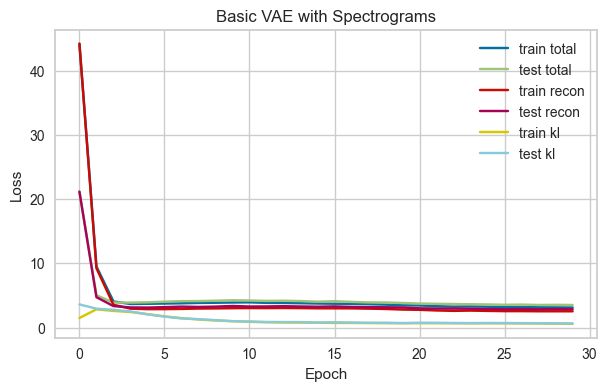

In [179]:
plot_history(history, "Basic VAE with Spectrograms")

## Extract Latent Features

In [180]:
def show_reconstructions(model, dataset, n=10, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    
    with torch.no_grad():
        for i in range(n):
            # Get a real sample
            print(dataset[i][1])
            x = dataset[i][0].unsqueeze(0).to(device)
            x_hat, _, _ = model(x)
            
            # Original Spectrogram
            img_org = x.squeeze().cpu().numpy()
            axes[i, 0].imshow(img_org, origin='lower', aspect='auto')
            axes[i, 0].set_title(f"Original {i}")
            
            # Reconstructed Spectrogram
            img_recon = x_hat.squeeze().cpu().numpy()
            axes[i, 1].imshow(img_recon, origin='lower', aspect='auto')
            axes[i, 1].set_title(f"Reconstructed {i}")
            
    plt.tight_layout()
    plt.show()

..\..\data\features\775_7.npy
..\..\data\features\MT0030097307_clip_6.npy


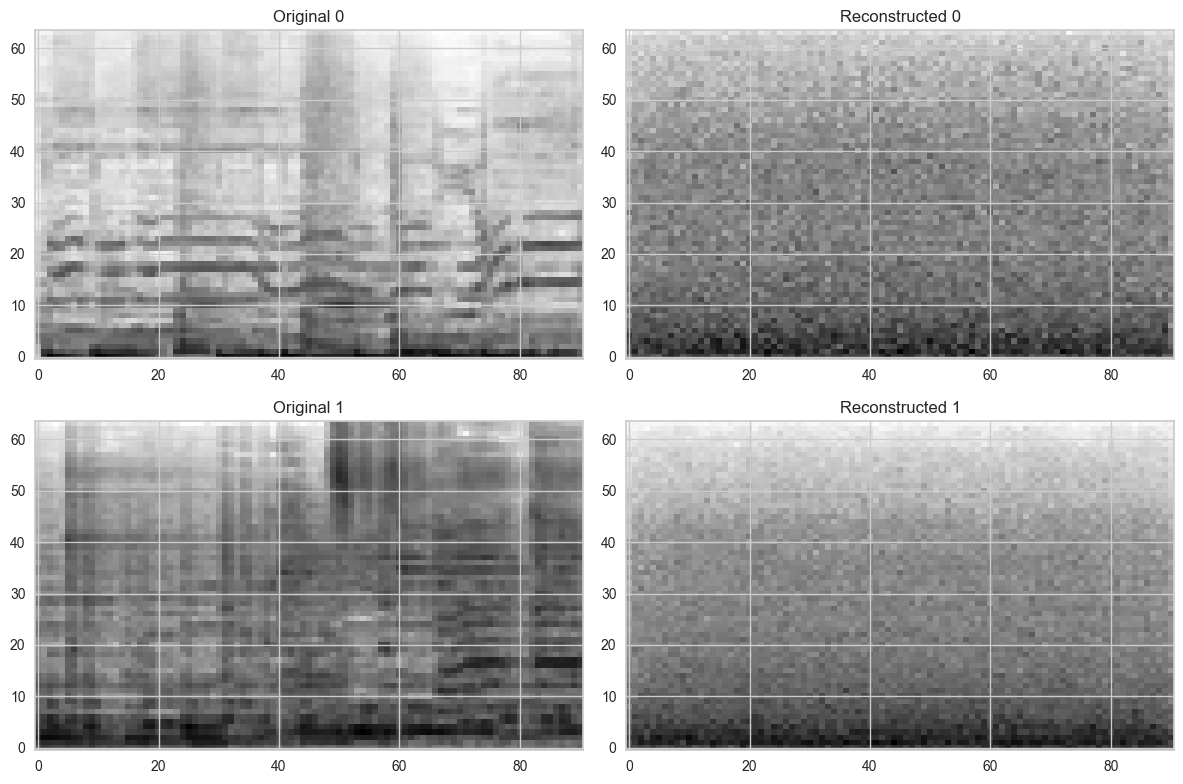

In [181]:
show_reconstructions(model=model, dataset=train_dataset, n=2)

In [182]:
def extract_latents(model, loader, device=device):
    model.eval()
    latents = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            latents.append(mu.cpu().numpy())
            
    return np.concatenate(latents)

In [183]:
latent_vecs1 = extract_latents(model=model, loader=train_loader)
latent_vecs2 = extract_latents(model=model, loader=test_loader)
latent_vecs = np.concatenate([latent_vecs1, latent_vecs2], axis=0)

print(f"Train shape: {latent_vecs1.shape}")
print(f"Test shape:  {latent_vecs2.shape}")
print(f"Total shape: {latent_vecs.shape}")

Train shape: (800, 32)
Test shape:  (200, 32)
Total shape: (1000, 32)


## K-means of Latent Features (Primary Model for Easy Task)

In [184]:
latent_vecs

array([[ 0.7508195 ,  0.03658044,  0.890098  , ...,  0.8469731 ,
        -0.28437012,  0.5816554 ],
       [ 0.85624766,  0.13202415,  1.5563525 , ...,  1.0457792 ,
        -0.07237719,  0.2793668 ],
       [ 0.8110988 ,  0.15715763,  2.1718736 , ...,  1.1170924 ,
        -0.1369546 ,  0.13943136],
       ...,
       [ 0.902629  ,  0.15823564,  1.7998289 , ...,  1.1269163 ,
        -0.08503547,  0.29224634],
       [ 0.92986405,  0.16318125,  2.3711753 , ...,  1.275772  ,
        -0.12496519,  0.13701496],
       [ 0.8745255 ,  0.17405313,  2.3542335 , ...,  1.2247267 ,
        -0.12907162,  0.10152671]], shape=(1000, 32), dtype=float32)

In [185]:
import pandas as pd
latent_vecs=pd.DataFrame(latent_vecs)
latent_vecs.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,0.750820,0.036580,0.890098,0.880287,-0.251087,-0.935019,0.961877,0.499941,-0.568443,-0.592033,...,0.674428,-0.721038,0.172832,-0.183806,0.241759,-0.301026,0.738432,0.846973,-0.284370,0.581655
1,0.856248,0.132024,1.556352,1.155349,0.118730,-0.638083,0.652043,0.332541,-0.273374,-0.374795,...,0.482391,-0.352840,0.207028,-0.071123,0.266339,-0.303113,0.443243,1.045779,-0.072377,0.279367
2,0.811099,0.157158,2.171874,1.127958,0.501924,-0.220705,0.311042,-0.004921,0.096074,-0.127858,...,0.188026,0.008847,0.311373,0.218064,0.279281,-0.215869,0.146958,1.117092,-0.136955,0.139431
3,0.770291,0.122716,2.522146,1.025022,0.745656,0.079687,0.014660,-0.228176,0.425580,0.115368,...,-0.085538,0.265861,0.366924,0.410915,0.279035,-0.079754,-0.139295,1.168343,-0.180611,-0.007925
4,0.904475,0.185911,2.580276,1.228257,0.643482,-0.148730,0.229998,-0.098463,0.177180,-0.084710,...,0.122459,0.089265,0.340290,0.339740,0.320670,-0.208398,0.082071,1.303807,-0.174064,0.101376


In [186]:
latent_vecs.describe()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.843031,0.138523,2.285543,1.130672,0.530630,-0.205474,0.278787,-0.024816,0.144043,-0.096448,...,0.146922,0.027183,0.318946,0.250077,0.288190,-0.184053,0.107792,1.185911,-0.160924,0.123577
std,0.115501,0.035052,0.470341,0.175837,0.303682,0.369183,0.324523,0.274802,0.339159,0.241341,...,0.295763,0.317802,0.070329,0.221880,0.057199,0.115151,0.310157,0.146266,0.058956,0.168974
min,0.362662,-0.041641,0.161353,0.404824,-0.432407,-1.459244,-0.275997,-0.560696,-0.841488,-0.871825,...,-0.530956,-1.063322,0.157751,-0.414701,0.094246,-0.484310,-0.536102,0.386639,-0.536366,-0.176582
25%,0.766538,0.118415,2.048964,1.016680,0.362346,-0.428544,0.037027,-0.230004,-0.077281,-0.243705,...,-0.080566,-0.158476,0.266177,0.097504,0.251105,-0.275622,-0.128675,1.095493,-0.195872,0.007114
50%,0.832318,0.144974,2.313534,1.120328,0.555595,-0.130565,0.202698,-0.080453,0.172114,-0.059930,...,0.119079,0.080497,0.309122,0.290658,0.286098,-0.173592,0.068977,1.196927,-0.160533,0.080249
75%,0.912132,0.163968,2.592736,1.228760,0.741595,0.066869,0.479468,0.150148,0.392018,0.081827,...,0.355681,0.254570,0.368445,0.410579,0.320794,-0.096396,0.314885,1.283310,-0.124702,0.210627
max,1.334483,0.234032,3.422016,1.919909,1.193678,0.505566,1.404993,0.870157,0.913400,0.417510,...,1.010075,0.671966,0.520330,0.709359,0.520437,0.095194,1.108991,1.760804,-0.029865,0.843925


In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

%matplotlib inline

In [188]:
track_inertia={}
silhouette={}
ch_index={}
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init = 'k-means++', random_state=42)
    kmeans.fit(latent_vecs)
    track_inertia[k] = kmeans.inertia_
    silhouette[k] = silhouette_score(latent_vecs, kmeans.labels_) 
    ch_index[k] = calinski_harabasz_score(latent_vecs, kmeans.labels_)

<Axes: >

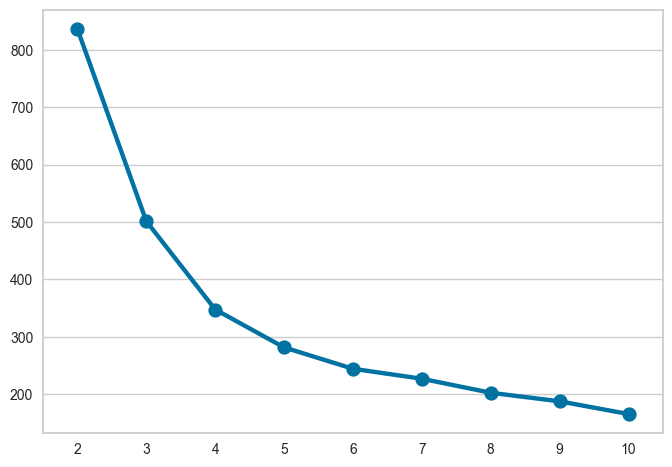

In [189]:
sns.pointplot(x = list(track_inertia.keys()), y = list(track_inertia.values()))

<Axes: >

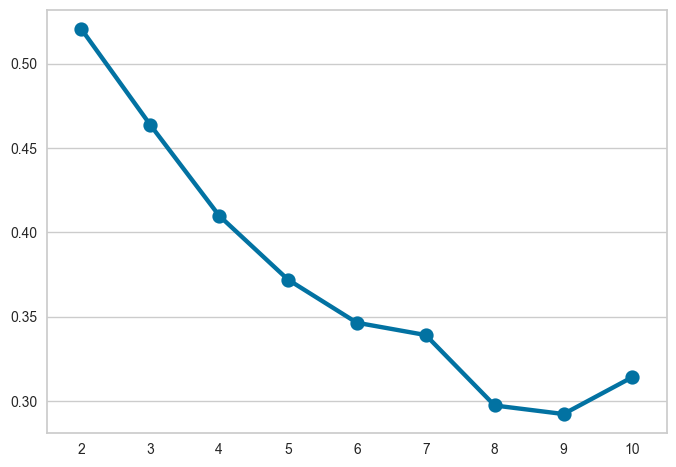

In [190]:
sns.pointplot(x = list(silhouette.keys()), y = list(silhouette.values()))

<Axes: >

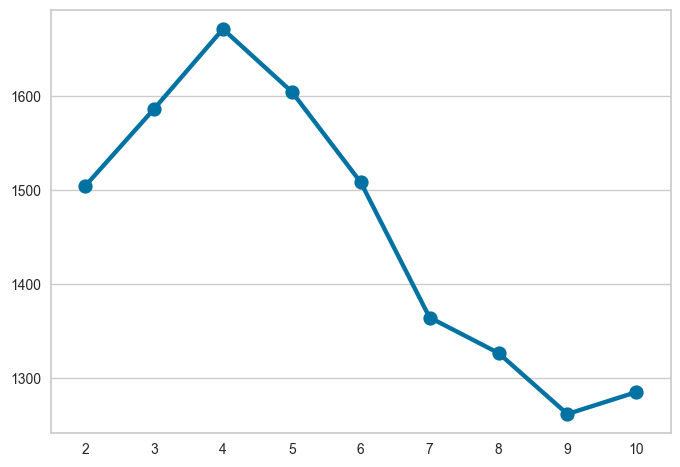

In [191]:
sns.pointplot(x = list(ch_index.keys()), y = list(ch_index.values()))

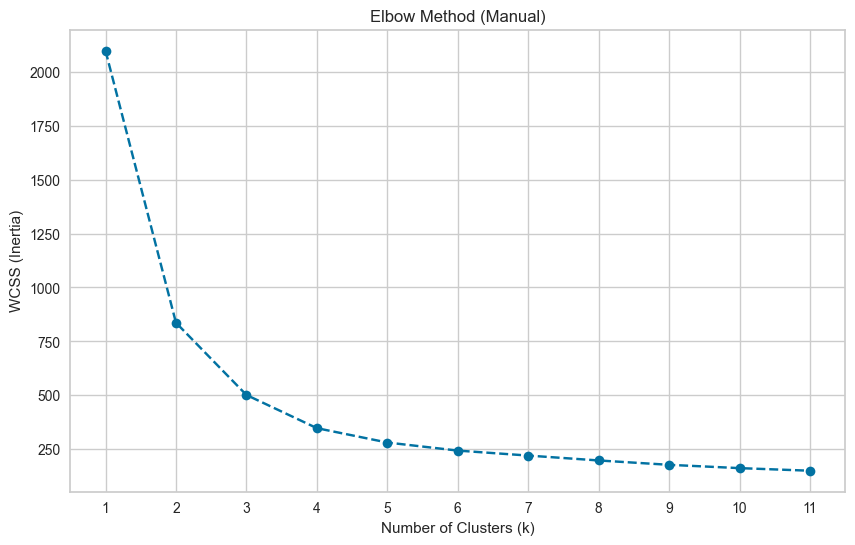

In [192]:
wcss = []
k_values = range(1, 12)

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=0)
    km.fit(latent_vecs)
    wcss.append(km.inertia_) # inertia_ is the "WCSS" value you need for the elbow


plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method (Manual)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

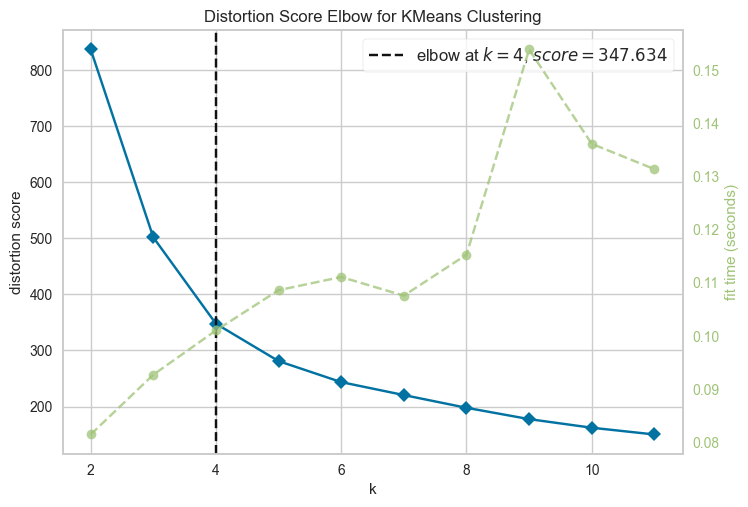

In [193]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model2 = KMeans(init='k-means++', random_state=0, n_init=10)

visualizer = KElbowVisualizer(model2, k=(2, 12), timings=True, force_model=True)

visualizer.fit(latent_vecs)        
visualizer.show()

optimal_k = visualizer.elbow_value_

In [194]:
optimal_k

np.int64(4)

In [195]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = optimal_k,init = "k-means++",max_iter = 300,n_init=10,random_state=0)
kmeans.fit(latent_vecs)
vae_clusters = kmeans.predict(latent_vecs)
vae_sil=silhouette_score(latent_vecs,kmeans.labels_)
print("WCSS for k: %d and Silhouette Score: %f"%(kmeans.inertia_,vae_sil))
print("calinski_harabasz_score: %f"%(calinski_harabasz_score(latent_vecs,kmeans.labels_)))

WCSS for k: 347 and Silhouette Score: 0.409904
calinski_harabasz_score: 1671.570801


## PCA + Kmeans (Baseline Model for Easy Task)

In [196]:
def loader_to_numpy(loader):
    xs = []
    for x,_ in loader:
        xs.append(x.view(x.size(0), -1).numpy())
    return np.concatenate(xs)

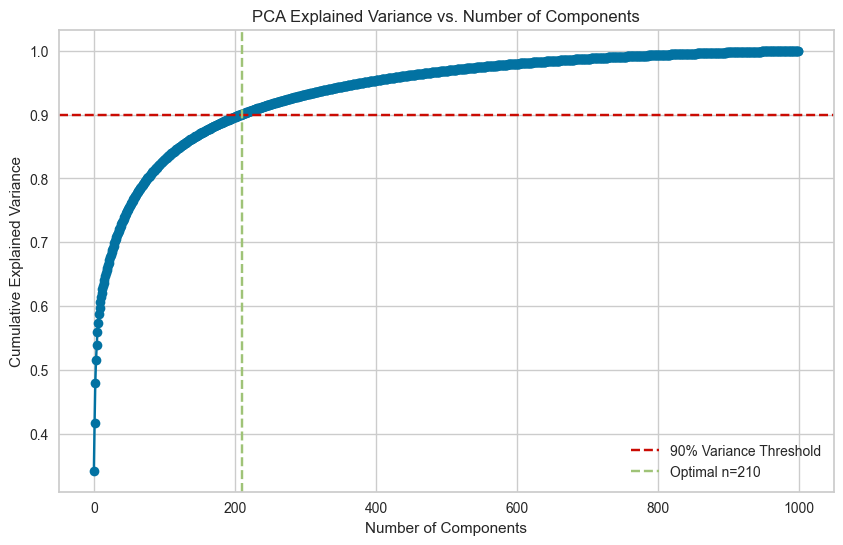

Optimal components for 90% variance: 210


In [197]:
from sklearn.decomposition import PCA

X_train = loader_to_numpy(train_loader)
X_test = loader_to_numpy(test_loader)

X_all = np.concatenate([X_train, X_test], axis=0)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca_full = PCA().fit(X_all)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
optimal_n = np.where(cumulative_variance >= 0.90)[0][0] + 1

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='-') # removed 'loc'
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.axvline(x=optimal_n, color='g', linestyle='--', label=f'Optimal n={optimal_n}')
plt.title('PCA Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print(f"Optimal components for 90% variance: {optimal_n}")

In [198]:
optimal_n

np.int64(210)

In [199]:
pca = PCA(n_components=optimal_n, random_state=42)
X_pca = pca.fit_transform(X_all)

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
pca_clusters = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, pca_clusters)
ch_idx = calinski_harabasz_score(X_pca, pca_clusters)

print(f"--- PCA + KMeans Baseline ---")
print(f"Silhouette Score: {round(sil, 4)}")
print(f"Calinski-Harabasz Index: {round(ch_idx, 4)}")

--- PCA + KMeans Baseline ---
Silhouette Score: 0.1444
Calinski-Harabasz Index: 173.9271


## Visualize t-sne for both models

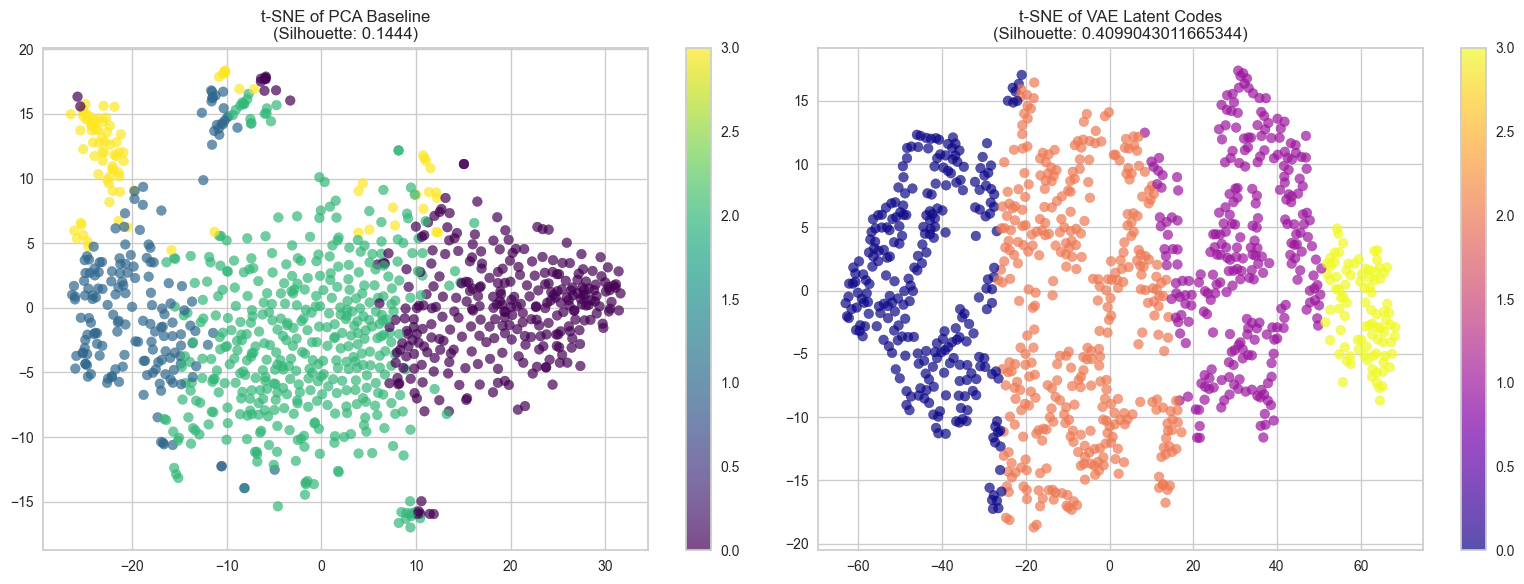

In [200]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_comparison(pca_latents, vae_latents, pca_clusters, vae_clusters):

    tsne_pca = TSNE(n_components=2, random_state=42).fit_transform(pca_latents)
    
    tsne_vae = TSNE(n_components=2, random_state=42).fit_transform(vae_latents)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    scatter1 = ax1.scatter(tsne_pca[:, 0], tsne_pca[:, 1], c=pca_clusters, cmap='viridis', alpha=0.7)
    ax1.set_title(f"t-SNE of PCA Baseline\n(Silhouette: {round(sil, 4)})")
    fig.colorbar(scatter1, ax=ax1)
    
    scatter2 = ax2.scatter(tsne_vae[:, 0], tsne_vae[:, 1], c=vae_clusters, cmap='plasma', alpha=0.7)
    ax2.set_title(f"t-SNE of VAE Latent Codes\n(Silhouette: {vae_sil})")
    fig.colorbar(scatter2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

plot_tsne_comparison(X_pca, latent_vecs, pca_clusters, vae_clusters)